In [73]:
import pandas as pd
import oracledb
from sqlalchemy import create_engine
from pathlib import Path
data_path = Path.cwd()/ 'data' / "titanic.csv"
df = pd.read_csv(data_path)
# df.head()
# df.tail()
df.info()




<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [74]:
pd.set_option("display.max_rows", 10)


In [75]:
df = df.astype({"PassengerId": "int", 
                "Survived": "bool",
                "Pclass": "category",
                "Sex": "category"})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    bool    
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    str     
dtypes: bool(1), category(2), float64(2), int64(3), str(4)
memory usage: 65.4 KB


In [76]:
pd.set_option("display.max_rows", 20)
df.isna().sum()
df_1 = df.isna()
df_1.mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [77]:
# df["Age"].astype("Int64")

In [78]:
import seaborn as sns

# sns.heatmap(df.isna(), cbar=False)

df.describe()


,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


In [79]:
df.iloc[0:5] 
corr_df = df[["PassengerId", "Age", "SibSp", "Parch","Fare"]].corr()
df.loc[:, ["PassengerId", "Age", "SibSp", "Parch","Fare"]].corr()
tmp = df.select_dtypes(include="number").corr()
type(tmp)
tmp.style.background_gradient(cmap="RdYlGn", vmin=-1, vmax=1)

# tmp = df.corr(numeric_only=True)
# type(tmp)
# tmp.style.background_gradient(cmap="RdYlGn", vmin=-1, vmax=1)
# sns.heatmap(corr_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

,PassengerId,Age,SibSp,Parch,Fare
PassengerId,1.000000,0.036847,-0.057527,-0.001652,0.012658
Age,0.036847,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.096067,0.159651,0.216225,1.000000


In [80]:
import pandas as pd
# concat, merge (left_on,right_on,how),join(index)
df1 = pd.DataFrame({
    "A": [1, 2,4]
})

df2 = pd.DataFrame({
    "A": [3, 4,5]
})

pd.concat([df1, df2], axis=1, ignore_index=True)

,0,1
0,1,3
1,2,4
2,4,5


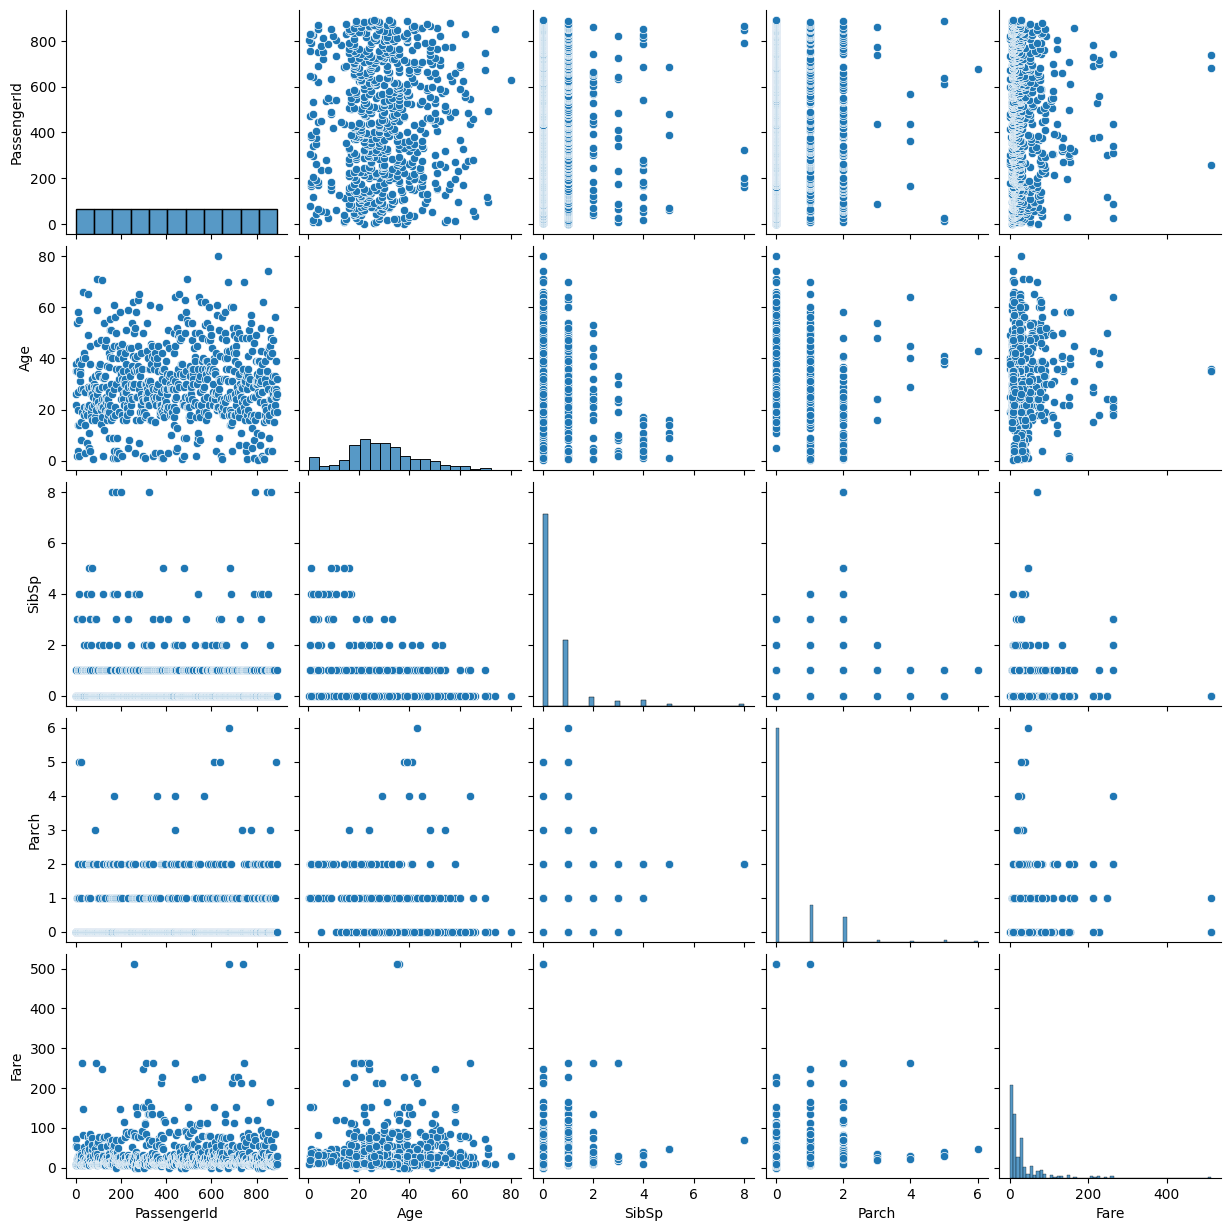

In [81]:
sns.pairplot(df.select_dtypes(include="number") )

In [ ]:
from sqlalchemy import text
oracle_user_name = "system"
db_oracle_password = "Oracle1234"
oracle_host = "localhost"
oracle_port = 1521
oracle_service_name = "xepdb1"



engine = create_engine(
    f"oracle+oracledb://{oracle_user_name}:{db_oracle_password}@{oracle_host}:{oracle_port}/?service_name={oracle_service_name}"
)

# with engine.connect() as conn:
#     conn.execute(text('''
#         CREATE USER GQY 
#         IDENTIFIED BY Oracle1234
#         DEFAULT TABLESPACE users
#         TEMPORARY TABLESPACE temp
#         QUOTA UNLIMITED ON users
#     '''))
#     conn.execute(text('''
#         GRANT CONNECT, RESOURCE TO GQY
#     '''))   
#     conn.commit()


In [97]:
oracle_user_name = "GQY"
db_oracle_password = "Oracle1234"
oracle_host = "localhost"
oracle_port = 1521
oracle_service_name = "xepdb1"

engine_gqy = create_engine(
    f"oracle+oracledb://{oracle_user_name}:{db_oracle_password}@{oracle_host}:{oracle_port}/?service_name={oracle_service_name}"
)
with engine_gqy.connect() as conn:
    try:
        conn.execute(text("DROP TABLE test"))
        conn.commit()
    except Exception as e:
        print(e)
    conn.execute(text("""
                               CREATE TABLE test (
                                   id NUMBER PRIMARY KEY,
                                   name VARCHAR2(50)
                               )
                               """))
    conn.execute(text("""
                               INSERT INTO test (id, name) VALUES (1, 'Alice')
                            
                               """))
    conn.commit()  
    result = conn.execute(text("SELECT * FROM test"))
    for row in result:
        print(row)

(oracledb.exceptions.DatabaseError) ORA-00942: table or view does not exist
Help: https://docs.oracle.com/error-help/db/ora-00942/
[SQL: DROP TABLE test]
(Background on this error at: https://sqlalche.me/e/20/4xp6)
(1, 'Alice')


In [109]:
import sqlite3

data_murder = Path.cwd()/"data"/"sql-murder-mystery.db"
conn = sqlite3.connect(data_murder)
cursor = conn.cursor()
cursor = cursor.execute("select name from sqlite_master where type='table'")
print(cursor.fetchall())
rst = pd.read_sql("select name from sqlite_master where type='table'", conn)
rst.head(10)


[('crime_scene_report',), ('drivers_license',), ('facebook_event_checkin',), ('interview',), ('get_fit_now_member',), ('get_fit_now_check_in',), ('solution',), ('income',), ('person',)]


,name
0,crime_scene_report
1,drivers_license
2,facebook_event_checkin
3,interview
4,get_fit_now_member
5,get_fit_now_check_in
6,solution
7,income
8,person


In [112]:
df_crime_scene_report = pd.read_sql("select * from crime_scene_report", conn)
df_crime_scene_report.head(10)
df_crime_scene_report.info()


<class 'pandas.DataFrame'>
RangeIndex: 1228 entries, 0 to 1227
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         1228 non-null   int64
 1   type         1228 non-null   str  
 2   description  1228 non-null   str  
 3   city         1228 non-null   str  
dtypes: int64(1), str(3)
memory usage: 38.5 KB
